#[Baseline] Data Analysis Competition: NFL Draft Prediction

In this notebook, you will build a **baseline model** for the task of predicting whether a player will be selected in the NFL Draft (**Drafted**) based on sports performance test results and player information.

A baseline model is a simple initial model built for a given machine learning task. It serves as a starting point for further model development and performance improvements.

By running this notebook from top to bottom, you will generate a prediction file that can be submitted successfully.

##Table of Contents
1. Setup

2. Load the Data

3. Data Analysis & EDA

4. Preprocessing

5. Baseline Model

6. Hypothesis & Feature Engineering

7. Create the Submission File

8. Next Steps

## 1.Setup

In [ ]:
# Import modules
import numpy as np  # Library for numerical computing and array operations
import pandas as pd  # Library for handling tabular data
import matplotlib.pyplot as plt  # Library for basic data visualization
import seaborn as sns  # Library for statistical data visualization
from sklearn.preprocessing import LabelEncoder  # Encoder for converting categorical variables to numeric labels
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.model_selection import StratifiedKFold  # Class for stratified K-fold cross-validation
from sklearn.metrics import roc_auc_score  # Metric function for computing ROC AUC

In this notebook, we assume the following directory structure in your Google Drive:
```
MyDrive/
└── GCI/
    └── competition/
        ├──README.ipynb
        ├── baseline.ipynb  # This notebook (baseline)
        └── input/
            ├── train.csv  # Training data
            ├── test.csv  # Test data (for prediction)
            └── sample_submission.csv  # Sample submission file

```

## 2.Load the data

### 2.1 Connect with Google Drive
To load the data, we first need to connect this Colab notebook with Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Next, we need to navigate to where the `competition` folder is located

**IMPORTANT**:<br>
Change the path in the `%cd` command below to match the folder where this notebook is saved on Google Drive by **replacing "WhereThisNotebookIsLocated" with your actual folder path**.

Examples:
- You uploaded `competition` folder directly under MyDrive (the default folder when you open Google Drive)
    - Change to "/<wbr>content/drive/MyDrive/competition"
- You uploaded `competition` folder inside a folder named `00_GCIGlobal` under MyDrive
    - Change to "/<wbr>content/drive/MyDrive/00_GCIGlobal/competition"

You can easily locate your notebook's directory by:
1. Open the Files panel on the left side of Colab
2. Navigate through the "drive" and "MyDrive" folders until you find your notebook's folders
3. Click the more actions icon (three vertical dots, $\vdots$) next to the folder name
4. Select the option "Copy path"

In [ ]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/00_GCIGlobal/competition"


/content/drive/MyDrive/00_GCIGlobal/competition


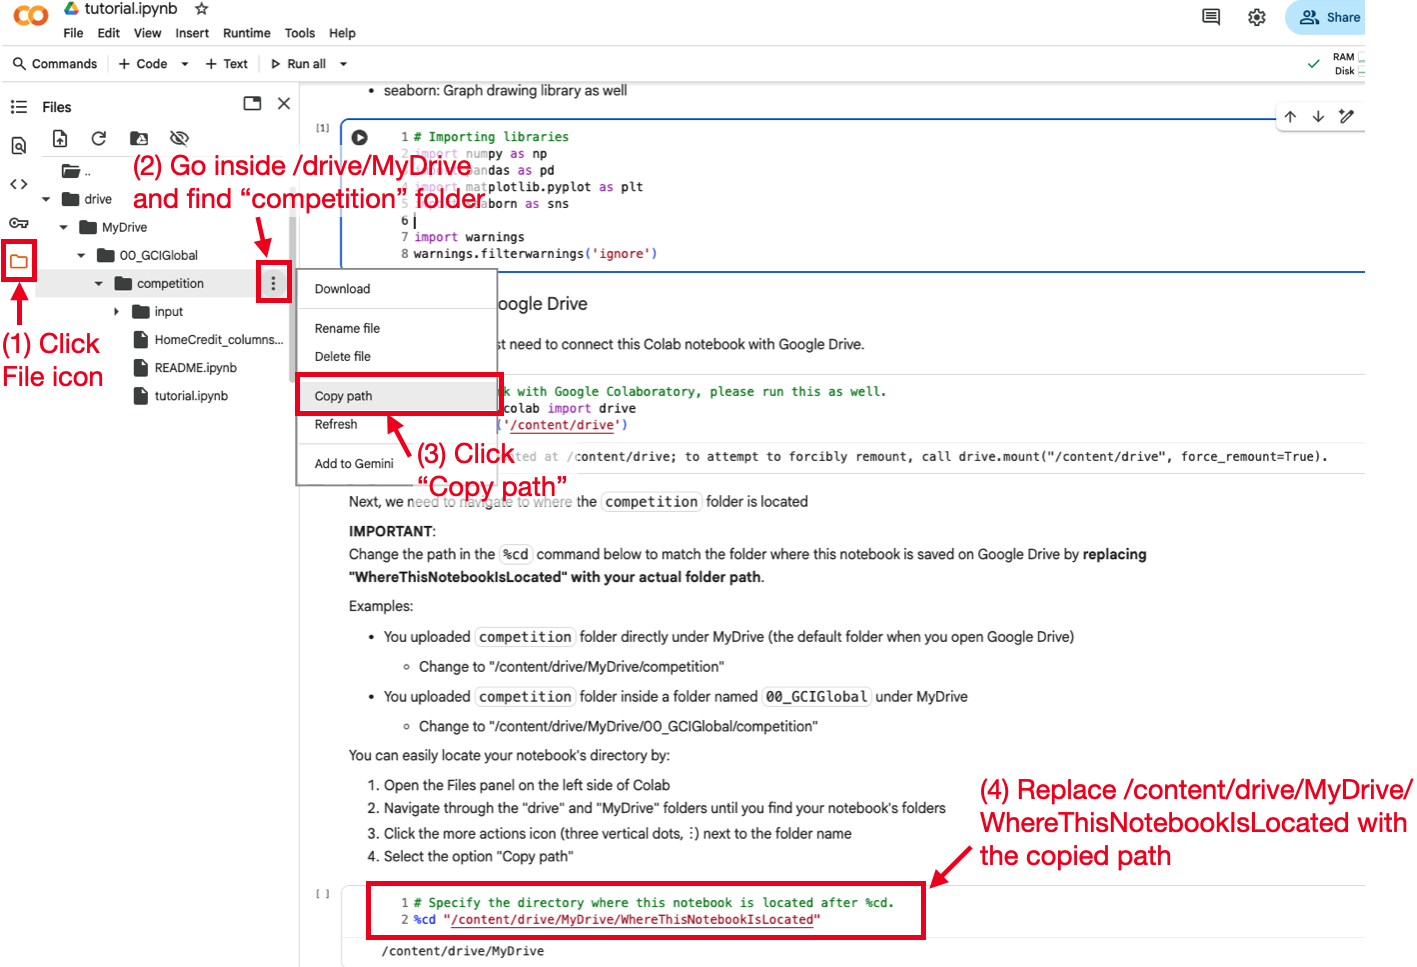

Run the cell below to check if the path is correctly set.

In [ ]:
from pathlib import Path

PATH = Path.cwd() / "input"

train_file = PATH / "train.csv"
test_file = PATH / "test.csv"
sample_sub_file = PATH / "sample_submission.csv"

# Check if path exists
if train_file.exists() and test_file.exists() and sample_sub_file.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


### 2.2 Data Overview
Run the cell to load the dataset as `pd.DataFrame`.

**IMPORTANT:**<br>
**When you make modifications to preprocessing or model training, always make sure to run all cells from this cell.**

In [ ]:
PATH = Path.cwd() / "input"

train = pd.read_csv(PATH / "train.csv")
test = pd.read_csv(PATH / "test.csv")
sample_sub = pd.read_csv(PATH / "sample_submission.csv")

print(f"train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}")

train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


First, let's check the shape of the dataset.

In [ ]:
print('Train:', train.shape)
print('Test:', test.shape)

Train: (2781, 16)
Test: (696, 15)


We can see that the training data contains **2,781 rows** and **16 columns**, while the test data contains **696 rows** and **15 columns**.
The test data has one fewer column because it does not include the target variable to be predicted.

Next, let's take a look at the **first five rows** of the training data.

In [ ]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


You can view detailed information about a pandas DataFrame by using `.info()`.

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

### [Next Steps]

This section only loaded the data. A few easy starting points to dig deeper before EDA:

- Run `train.describe()` and `test.describe()` to see summary statistics for the numerical columns.
- Check for duplicate rows with `train.duplicated().sum()`.
- Compare basic statistics (mean, std, min, max) between **train** and **test** to check whether the two splits look similar.

## 3.Data Analysis & EDA

**EDA (Exploratory Data Analysis)** is an essential step for understanding the structure and characteristics of your data before building a model.

At this stage, you explore trends and patterns in the dataset, as well as **outliers**, **missing values**, and **imbalanced distributions**. For example, some variables may contain extreme values, or the data may be heavily skewed toward specific categories. Identifying these characteristics helps you find potential issues that could hurt performance and uncover features that may be useful for prediction.

By performing EDA, you can detect and address problems early—such as “training fails due to missing values” or “the model becomes unstable because of outliers.” This reduces rework later and enables more efficient preprocessing and feature engineering.

Insights from EDA also inform later decisions, including model selection and hyperparameter tuning. In machine learning competitions, EDA is often a key process for improving final scores.

### 3.1 Checking Missing Values

First, let's check for missing values. This is an essential step in machine-learning-based data analysis, because most machine learning models cannot train on or make predictions from data that contains missing values, and will raise an error.

In [ ]:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


In [ ]:
test.isnull().sum()

,0
Id,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147


We found missing values in the following columns: **Age**,**Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone**, and **Shuttle**. We will handle these later.

### 3.2 Visualization and Analysis

Next, let's look at how many players were drafted.

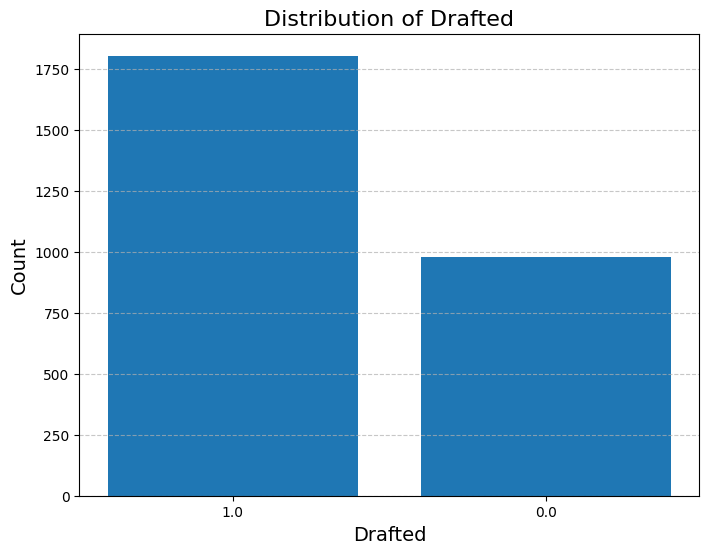

In [ ]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

We can see that there are more players with **Drafted = 1** than those with **Drafted = 0**. Let's check the propotions.

In [ ]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


We found that about **35%** of the players were **not drafted**, while about **65%** were **drafted**.

Next, we will continue EDA for the other features. First, let's visualize the numerical variables excluding the **"Id"** and **"Drafted"** columns.

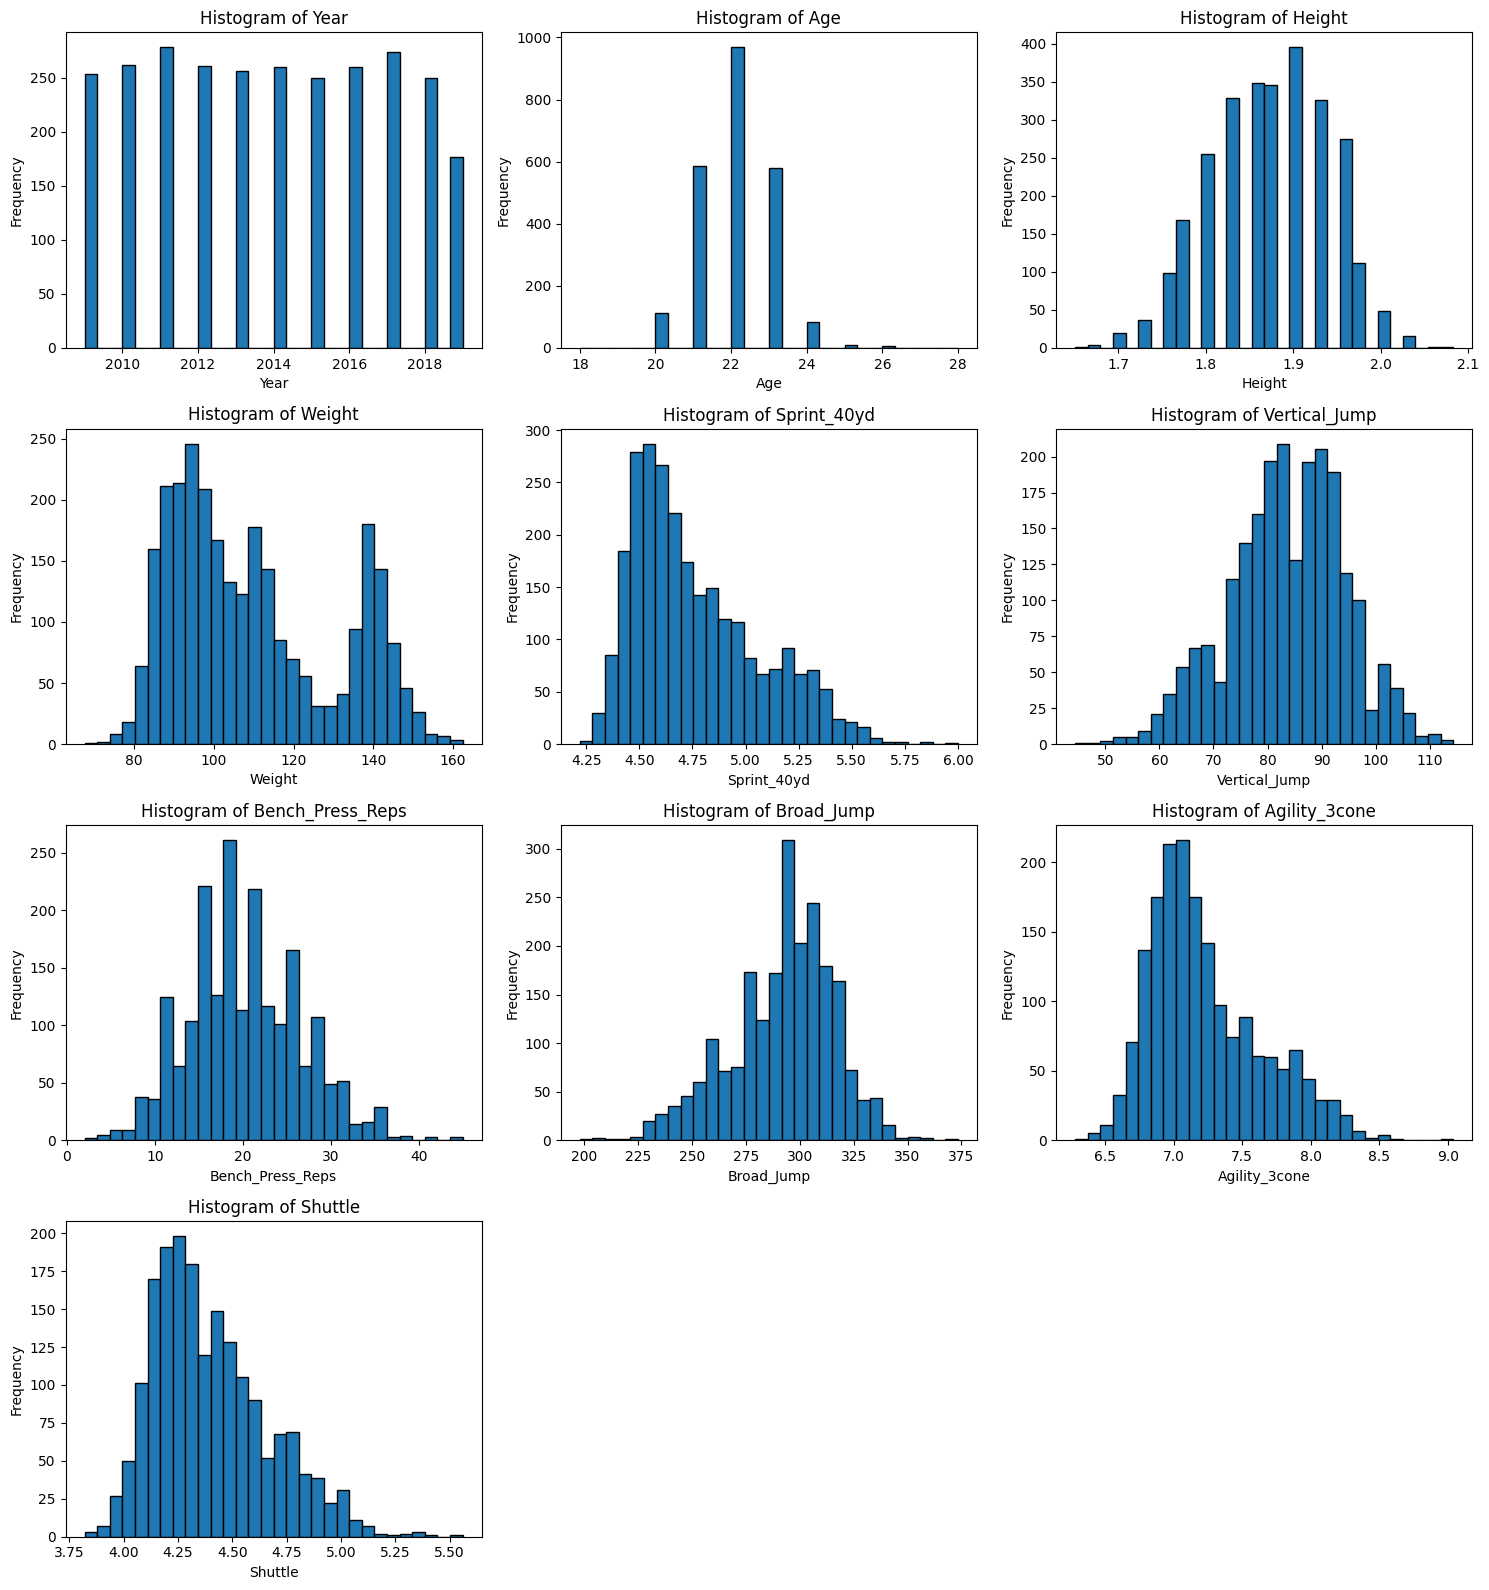

In [ ]:
# Extraxt numeric columns (excluding the 'Id' and 'Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# Plot
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=30, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Let's examine the correlation matrix of the numerical features using a heatmap.

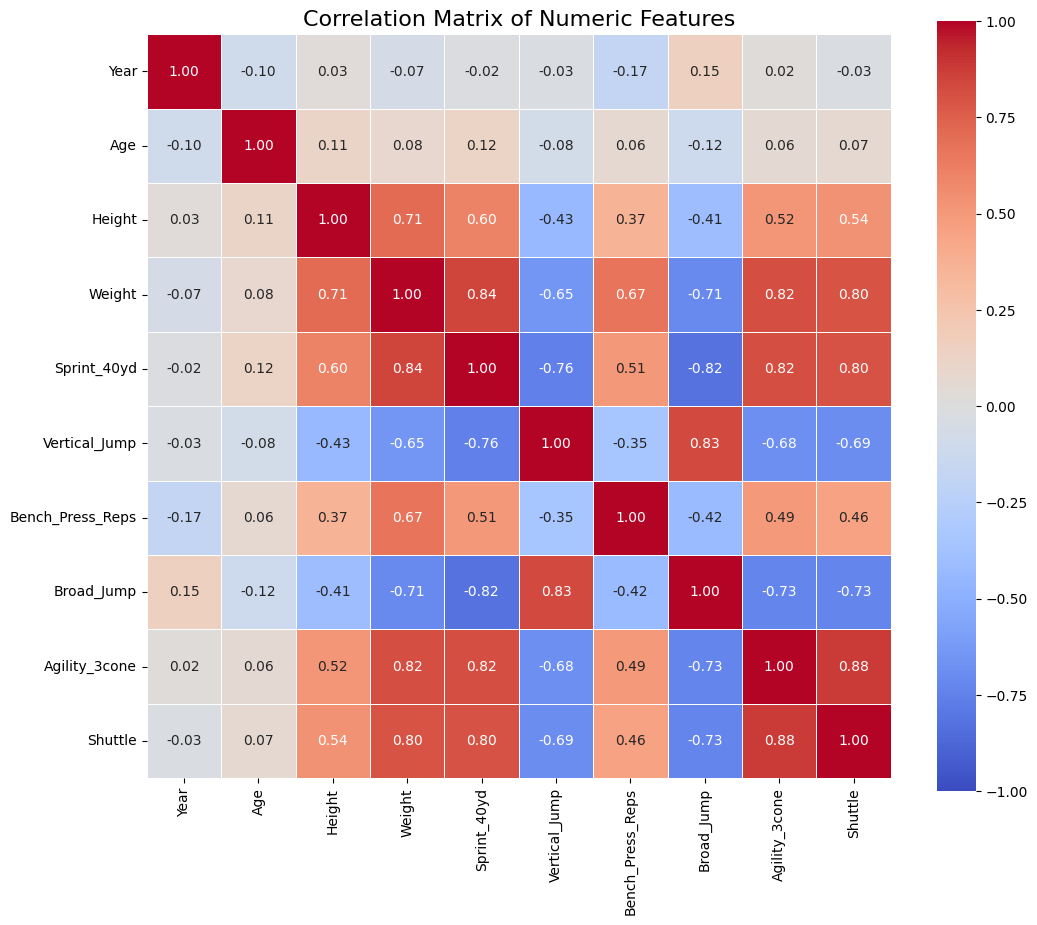

In [ ]:
# Extract numeric columns (excluding the 'Id' and ''Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

The correlation coefficient between **Agility_3cone** and **Shuttle** is **0.88**, indicating a strong positive relationship. These tests may rely on similar muscle groups and movement patterns.

On the other hand, the correlation coefficient between **Sprint_40yd** and **Broad_Jump** is **-0.82**, showing a strong negative relationship. Since both events mainly depend on lower-body power, we might normally expect their scores to move together (i.e., a positive correlation), but here we observe the opposite. To investigate this further, let’s visualize **Sprint_40yd**.

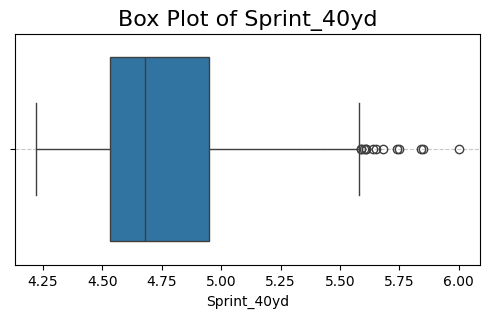

In [ ]:
# Plot a boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the plot, we can see that values in **Sprint_40yd** are roughly distributed between **4.25** and **6.00**. This suggests the column likely represents the **actual sprint time**, not a “score.” A median of around **4.7 seconds** is reasonable for a 40-yard (about 36-meter) dash.

In other words, **smaller values** in **Sprint_40yd** mean faster times, so **lower is better**—the opposite direction from metrics where **higher values indicate better performance**. This explains why we observed a negative correlation with **Broad_Jump**.

By visualizing the data, we were able to answer the question: **“Why is there a negative correlation?”**

Next, let's visualize the categorical features.

In [ ]:
# Extract categorical features
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# Get the number of unique categories in each column
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


**'School'** has **236** unique values, which is too many to visualize clearly, so we will exclude it from the plots here.

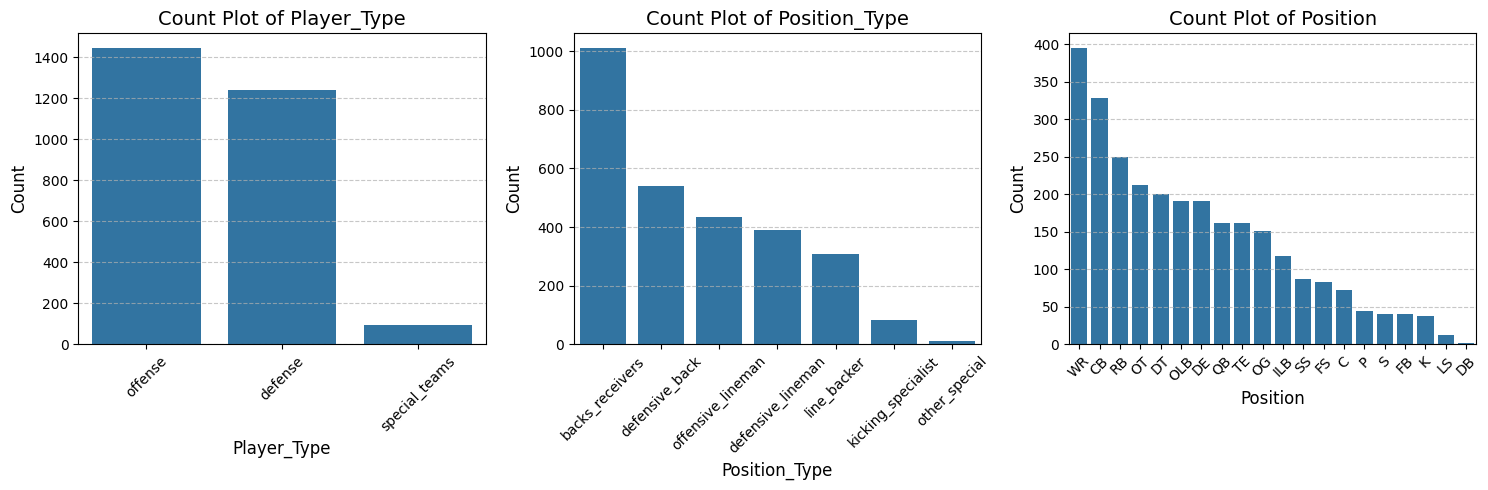

In [ ]:
# Extract categorical features (object or category) and exclude the 'School' columns
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Count plots for each categorical features
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

We can see that the number of samples varies widely across categories. For example, in the **Player_Type** column, the **special_teams** category has very few samples.

Next, let's visualize the **mean value of "Drafted"** for each category level. This helps us understand, visually, which positions are more likely to be drafted.

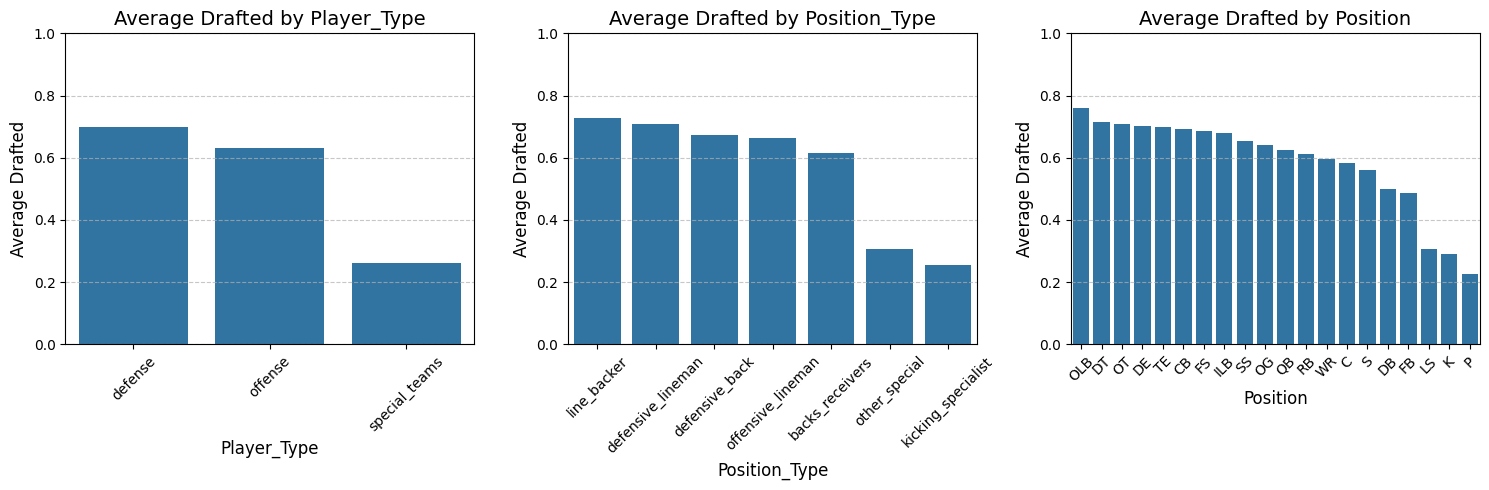

In [ ]:
# Extract categorical features (object or category) and exclude the 'School' column
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot the mean value of 'Drafted' for each categorical feature as bar charts
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


We can see that players with **Player_Type = "special_teams"** have a much lower draft rate than other players.
Similarly, players with **Position_Type = "other_special"** or **"kicking_specialist"**, and those with **Position = "LS"**, **"K"**, or **"P"**, also have relatively low draft rates.

### [Next Steps]

EDA is open-ended; here are some directions you can take next:

- Examine the relationship between each numerical feature and the target with grouped boxplots (`sns.boxplot(x='Drafted', y=col, ...)`).
- Cross-tabulate categorical features against **Drafted** to see which categories have a high or low draft rate.
- Investigate the **School** column more carefully — for example, group schools by conference or region and check the draft rate per group.
- Look for outliers in other numerical columns (e.g. **Bench_Press_Reps**, **Vertical_Jump**) and decide how to handle them.

## 4.Preprocessing

Here, we will conduct the preprocessing and create new features based on what we have learned in the preceding visualization and analysis. We will perform **missing value imputation** and **encoding**.

### 4.1 Dropping Columns

In this notebook, we will exclude categorical features with a relatively large number of unique levels. Specifically, we will drop the **School** column (**236** unique values). *(Note: School may still influence Drafted; if you want to explore further, try including it as a feature.)* We will also drop the **Id** column, since it is expected to be unrelated to whether a player is drafted.

In [ ]:
# Drop unused columns
train = train.drop(columns=["Id", "School"])
test = test.drop(columns=["Id","School"])

### 4.2 Dealing Missing Values

There are missing values in **Age**, **Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone**, and **Shuttle**. In this notebook, we will impute these missing values using the mean of each column.

In [ ]:
# Columns to impute with the mean
cols_to_fill = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle']

# Impute both train and test using the means computed from the training data
for col in cols_to_fill:
    mean_value = train[col].mean()
    train[col] = train[col].fillna(mean_value)
    test[col] = test[col].fillna(mean_value)

Let's check whether there are any missing values.

In [ ]:
train.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [ ]:
test.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


Now, the missing values in both **train** and **test** have been handled.

### 4.3 Dealing Categorical Data

Next, let's convert the categorical features into numerical values so they can be used as model imputs. Most machine learning models can only accept numerical data.

Here, we will use a technique called **label encoding**.

In [ ]:
# Label-encode the categorical features
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

### [Next Steps]

The preprocessing here is intentionally minimal. You can likely improve the score by changing how features are prepared:

- **Imputation**: try the median, a group-wise mean (e.g. mean by **Position**), or a model-based imputer such as `KNNImputer`.
- **Encoding**: try **One-Hot Encoding**, **Target (Mean) Encoding**, or **Frequency Encoding** instead of label encoding.
- **School**: rather than dropping it, try encoding it (e.g. target encoding or frequency encoding).
- Add a **missing-value indicator** (a 0/1 column that records whether the original value was missing).

## 5.Baseline Model

Now that the data has been prepared, we will use it as input to build a **baseline model**. A baseline model is a simple initial machine learning model that serves as a starting point.

In this notebook, we will use a **Random Forest** model, which is a tree-based method that makes predictions by combining many **decision trees**.

A decision tree is an intuitive model that repeatedly splits the data using simple “yes/no” questions. For example: “Is the player taller than 170 cm?” or “Is the player a kicker?” By following these conditions step by step, the model arrives at a final prediction.

However, using a single decision tree often leads to a model that fits the training data too closely and does not generalize well to new data—this is called **overfitting**. Random Forest addresses this by training dozens (or even hundreds) of decision trees, each on slightly different subsets of the data and features. It then combines their predictions—typically by averaging—resulting in a more stable and robust model.

To evaluate the model's performance, we will use **cross-validation**. This method splits the dataset into several groups (folds) and repeats training and evaluation multiple times.

In this notebook, we use **5-fold cross-validation**: the data is split into five folds, and each time we use one fold for validation and the remaining four folds for training. We repeat this process five times and take the average score as an estimate of model performance. Cross-validation is ueful because it provides a more reliable evaluation than a single train/validation split.

In [ ]:
# Split into features and target
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# Set up the model and cross-validation
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Predict and score
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.7905
Fold 2
  AUC: 0.8306
Fold 3
  AUC: 0.8329
Fold 4
  AUC: 0.7729
Fold 5
  AUC: 0.8308

Average Validation AUC: 0.8115


This model achieved an AUC score of **0.8115**.

### [Next Steps]

The baseline uses a default Random Forest. Common ways to improve from here:

- Try other models: **Logistic Regression**, **LightGBM**, **XGBoost**, or **CatBoost**.
- Tune hyperparameters such as `n_estimators`, `max_depth`, and `min_samples_leaf`. Start with a small grid and expand once you see what helps.
- Compare a few `random_state` values or change the number of folds (`n_splits`) to check that the score is stable.

## 6. Hypotheses & Feature Engineering

Here, we will perform **feature engineering**.

Feature engineering is the process of creating new features from the original data so that the model can learn more effectively. It is one of the key steps for improving model performance.

Here, based on the hypothesis that **BMI**, a measure of body composition caluculated from height and weight, may be informative for predicting draft outcomes, we will create a new feature by computing.

**BMI = weight / (height)²**

In [ ]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

Let's re-evaluate the model, this time including the newly created feature.

In [ ]:
# Split into features and target
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# Set up the model and cross-validation
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Validation prediction & scoring
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print the mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.7861
Fold 2
  AUC: 0.8359
Fold 3
  AUC: 0.8374
Fold 4
  AUC: 0.7776
Fold 5
  AUC: 0.8277

Average Validation AUC: 0.813


With feature engineering, the AUC score improved from **0.8115** to **0.813**.

As shown here, adding new features can sometimes have a positive impact on model performance. Try forming your own hypotheses and creating additional features based on the structure and meaning of the data.

Some machine learning models can compute the importance of the input features. Let's visualize the feature importances.

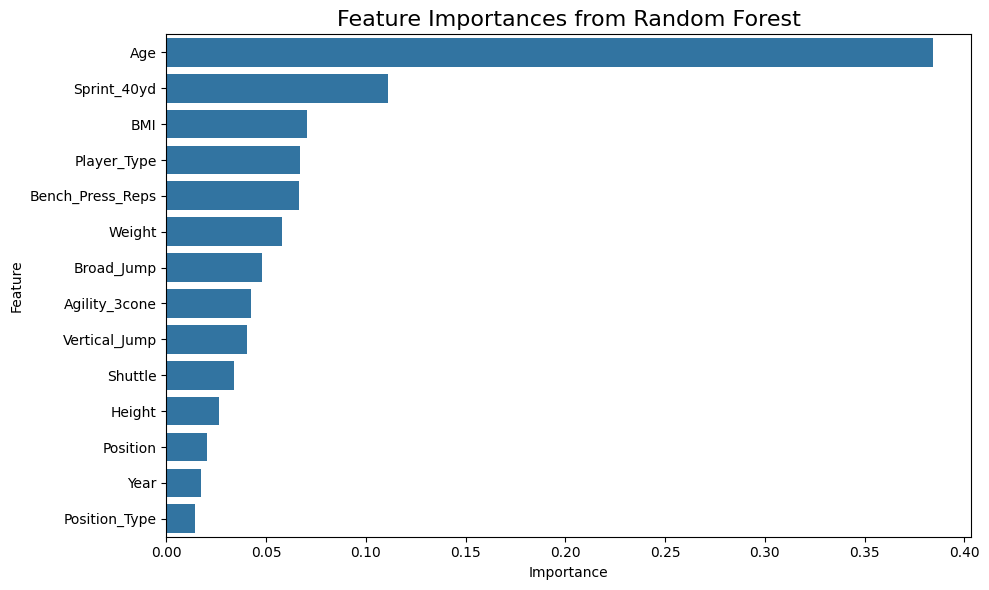

In [ ]:
# Create a DataFrame of features and their importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from Random Forest', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The newly created feature, **BMI**, showed relatively high feature importance.

### [Next Steps]

We added only **BMI**. Many more features can be designed from this dataset:

- Build domain-driven features: ratios such as `Weight / Sprint_40yd`, or **Position**-specific summaries.
- Create interaction features between physical tests (e.g. `Vertical_Jump × Broad_Jump`).
- Use the feature-importance plot above to decide which features to keep, drop, or transform.
- Try binning numerical variables (e.g. **Age** into ranges) and treating them as categorical.

## 7.Create the Submission File

Finally, let's make a prediction for the test data, and prepare a CSV file to submit.

### 7.1 Predicting on the test data
We found in Sections 5 and 6 that the best model was Random Forest model with BMI column added. Therefore, we will use this model to make the final prediction.

If you made any changes and found a better model, you will need to change the code below accordingly.

In [ ]:
# Store predictions
test_pred_proba_list = []

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Save predictions for the test set
    test_pred_proba = model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# Average test predictions across folds
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

### 7.2 Saving the prediction as CSV file [DO NOT CHANGE]
**WARNING**: DO **NOT** CHANGE THE CODES BELOW!!!

In [ ]:
# Running this cell will generate the submission CSV file
submission = pd.read_csv(PATH / 'sample_submission.csv') # Update PATH in needed
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH / 'submission.csv', index=False)


At this point, you have successfully created a prediction CSV file that is ready for submission. Try submitting **submission.csv**.

## 8.Next Steps

In this notebook, we built a baseline model end to end—from preprocessing and feature engineering to model training and evaluation.

From here, you can use this baseline as a foundation and aim for higher accuracy by designing more advanced features and improving the modeling approach. For example, you might explore the following:

- Try different encoding methods for categorical features
- Try alternative missing-value imputation strategies
- Experiment with other models
- Tune model hyperparameters
- Develop additional feature engineering ideas

Let’s work toward a higher score!